# Lab 1: Building Quantum Circuits for Real Hardware

## Qiskit Global Summer School 2026

Welcome to Lab 1! In this notebook you will learn how to build quantum circuits from the ground up and prepare them for execution on real quantum hardware.

**What you'll learn:**

1. [**Part 1: Basic Gates & Quantum Concepts**](#part1): How X, H, and CX gates create superposition and entanglement
2. [**Part 2: Circuit Depth**](#part2): Why depth matters, GHZ states, and how to reduce depth using symmetry
3. [**Part 3: Transpilation**](#part3): Adapting circuits to the constraints of a real processor (the IBM 133-qubit Heron chip)

Each part builds on the last, and by the end you'll be constructing efficient 64-qubit entangled states for real hardware, skills that carry directly into Lab 2.

## Before you begin

> **This lab runs entirely on a local *simulator* (`FakeTorino`) on qBraid.** Every circuit is built in C++, transpiled, and executed locally — you will **not** consume any IBM Quantum runtime minutes. *Submitting* your answers to the grader does require a configured IBM Quantum account; see the account-setup cell in the Setup section if a grade cell reports an authentication error.

<details>
<summary><b>Common setup issues (click to expand)</b></summary>

- **Run the Setup cells in order.** The paths cell defines `LAB_ROOT`/`QISKIT_CPP_SRC`; the CMake cell configures the build. Re-run the Setup section if you restart the kernel.
- **`nlohmann/json.hpp` not found at build?** The CMake configure step fetches it over the network; if your qBraid session lacked network at configure time, re-run the CMake cell once connectivity is back.
- **A grade cell fails with an authentication error?** Your qBraid session does not inherit the IBM Quantum account you saved in Lab 0 — run the account-setup cell in the Setup section once.
- **ASCII circuit drawings look misaligned?** Re-run the monospace-CSS cell in the Setup section.
</details>

## Setup

Run the cells in this **Setup** section once, top to bottom, before starting Part 1. This lab is supported on **qBraid**, where the C++ lab files and a built `qiskit-cpp` are already provided in your environment.

**Note:** This lab writes C++ code via `%%writefile` cells. qBraid's editor may flag these cells because it expects Python — those warnings are cosmetic and can be ignored.

In [2]:
# qBraid setup: locate (or fetch) the qiskit-cpp source and set lab paths.
# Run this cell first; later cells reference LAB_ROOT and QISKIT_CPP_SRC.
# qBraid is the only supported platform. The lab tree ships with this notebook;
# qiskit-cpp is fetched here (pinned) if it isn't already present.
import os, subprocess
from pathlib import Path

# qiskit-cpp commit this lab is tested against. Newer commits may call Qiskit C
# API symbols not present in the installed qiskit (e.g. qk_circuit_global_phase),
# so we pin a known-good version.
QISKIT_CPP_PIN = "91f4b5d64f69903224058521421b8305ae9d64e3"

# LAB_ROOT is the directory that contains this notebook (the C++ lab tree).
LAB_ROOT = str(Path.cwd().resolve())

# QISKIT_CPP_SRC must point at the qiskit-cpp "src" directory (header-only SDK).
# Resolution: explicit QISKIT_CPP_SRC env var -> known locations -> search upward.
def _find_qiskit_cpp_src():
    env = os.environ.get("QISKIT_CPP_SRC")
    if env and (Path(env) / "circuit" / "quantumcircuit.hpp").is_file():
        return str(Path(env).resolve())
    p = Path(LAB_ROOT).resolve()
    candidates = [
        Path.home() / "qiskit-cpp" / "src",
        Path("/opt/qiskit-cpp/src"),
        *[parent / "qiskit-cpp" / "src" for parent in [p, *p.parents]],
    ]
    for c in candidates:
        if (c / "circuit" / "quantumcircuit.hpp").is_file():
            return str(c.resolve())
    return None

QISKIT_CPP_SRC = _find_qiskit_cpp_src()
if QISKIT_CPP_SRC is None:
    # Not present (qBraid doesn't pre-load it) -- clone the pinned version into ~/qiskit-cpp.
    dest = Path.home() / "qiskit-cpp"
    print(f"qiskit-cpp not found; cloning pinned {QISKIT_CPP_PIN[:8]} into {dest} ...")
    subprocess.run(["git", "clone", "--quiet",
                    "https://github.com/Qiskit/qiskit-cpp.git", str(dest)], check=True)
    subprocess.run(["git", "-C", str(dest), "checkout", "--quiet", QISKIT_CPP_PIN], check=True)
    QISKIT_CPP_SRC = _find_qiskit_cpp_src()

print(f"LAB_ROOT       : {LAB_ROOT}")
if QISKIT_CPP_SRC:
    print(f"QISKIT_CPP_SRC : {QISKIT_CPP_SRC}")
else:
    raise RuntimeError(
        "Could not locate or fetch qiskit-cpp. Set it explicitly and re-run, e.g.:\n"
        "    import os; os.environ['QISKIT_CPP_SRC'] = '/path/to/qiskit-cpp/src'"
    )

# If a C++ build later fails with an unknown qk_* symbol, an existing qiskit-cpp
# checkout is newer than this lab targets -- pin it:
#     git -C ~/qiskit-cpp checkout 91f4b5d6

LAB_ROOT       : /home/h-livv/Projects/qgss-2026/lab-1/cpp
QISKIT_CPP_SRC : /home/h-livv/qiskit-cpp/src


In [3]:
# Force strict-monospace + horizontal-scroll on stream output so the
# C++ binaries' ASCII circuit drawings render with aligned columns in
# qBraid's JupyterLab.
from IPython.display import HTML, display
display(HTML("""
<style>
.jp-OutputArea-output pre,
.jupyter-widgets-output-area pre,
.output pre {
    white-space: pre !important;
    overflow-x: auto !important;
    font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace !important;
}
</style>
"""))

In [4]:
# Run this cell if these packages aren't already installed in your qBraid environment.
# (Uses the %pip magic so packages install into the *running* kernel — important on
# qBraid, where a plain !pip can target the wrong environment.)
%pip install "qiskit>=2.4.1" qiskit-ibm-runtime qiskit-aer numpy networkx matplotlib qiskit-qasm3-import
%pip install --upgrade git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/qiskit-community/Quantum-Challenge-Grader.git to /tmp/pip-req-build-mv6by7ac
  Running command git clone --filter=blob:none --quiet https://github.com/qiskit-community/Quantum-Challenge-Grader.git /tmp/pip-req-build-mv6by7ac
  Resolved https://github.com/qiskit-community/Quantum-Challenge-Grader.git to commit faf227a16ca09ed2dd6701b767521699965674dd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [5]:
# On qBraid the C++ lab files are already present in this directory (LAB_ROOT).
# Verify the lab tree looks right before configuring the build.
from pathlib import Path
if (Path(LAB_ROOT) / "CMakeLists.txt").is_file():
    print(f"Lab files found at {LAB_ROOT}")
else:
    raise RuntimeError(
        f"Could not find the C++ lab tree (CMakeLists.txt) at {LAB_ROOT}. "
        "Open this notebook from inside the lab directory on qBraid."
    )

Lab files found at /home/h-livv/Projects/qgss-2026/lab-1/cpp


In [6]:
# qiskit-cpp was located by the paths cell above (QISKIT_CPP_SRC). Confirm it here.
from pathlib import Path
assert QISKIT_CPP_SRC and (Path(QISKIT_CPP_SRC) / "circuit" / "quantumcircuit.hpp").is_file(), (
    f"qiskit-cpp headers not found at QISKIT_CPP_SRC={QISKIT_CPP_SRC!r}. "
    "Re-run the paths cell above."
)
print(f"qiskit-cpp headers : {QISKIT_CPP_SRC}")

qiskit-cpp headers : /home/h-livv/qiskit-cpp/src


In [7]:
# Ensure per-example directories and placeholder source files exist so
# CMake can configure all targets. Non-destructive: existing source files
# are not overwritten.
EXAMPLES = [
    'x_gate_circuit', 'h_gate_circuit', 'bell_state', 'bell_exercise',
    'bell_phase', 'bell_phase_exercise', 'ghz_3qubit', 'ghz_fan_chain',
    'depth_examples', 'depth_exercise', 'ghz_depth', 'ghz_half_depth',
    'ghz_exercise', 'bridge_verify', 'bridge_exercise', 'ghz_line_exercise',
    'ghz_hex_exercise', 'ghz_64_exercise', 'transpile_setup', 'transpile_demo',
    'topology_viz',
]

for name in EXAMPLES:
    d = Path(LAB_ROOT) / name
    d.mkdir(parents=True, exist_ok=True)
    src = d / f'{name}.cpp'
    if not src.exists():
        src.touch()

print(f'Lab directories ready under {LAB_ROOT}')

Lab directories ready under /home/h-livv/Projects/qgss-2026/lab-1/cpp


In [8]:
# Configure the build. We put the running kernel's Python first on PATH so CMake's
# `python3` probe resolves to the interpreter that has Qiskit (its C API headers/lib);
# paths are quoted so directories containing spaces work.
import os, sys
os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ["PATH"]
!cmake -S "{LAB_ROOT}" -B "{LAB_ROOT}/build" -DQISKIT_CPP_SRC="{QISKIT_CPP_SRC}"

-- Qiskit C API include: /home/h-livv/Projects/qgss-2026/.venv/lib64/python3.13/site-packages/qiskit/capi/include
-- Qiskit C API library: /home/h-livv/Projects/qgss-2026/.venv/lib64/python3.13/site-packages/qiskit/_accelerate.abi3.so
-- qiskit-cpp headers: /home/h-livv/qiskit-cpp/src
-- Python library: /usr/lib64/libpython3.14.so
CMake Warning (dev) at /usr/share/cmake/Modules/FetchContent.cmake:1386 (message):
  The DOWNLOAD_EXTRACT_TIMESTAMP option was not given and policy CMP0135 is
  not set.  The policy's OLD behavior will be used.  When using a URL
  download, the timestamps of extracted files should preferably be that of
  the time of extraction, otherwise code that depends on the extracted
  contents might not be rebuilt if the URL changes.  The OLD behavior
  preserves the timestamps from the archive instead, but this is usually not
  what you want.  Update your project to the NEW behavior or specify the
  DOWNLOAD_EXTRACT_TIMESTAMP option with a value of true to avoid this
 

In [9]:
# Import the grader client and OpenQASM 3 reader (used by the grade cells).
from qc_grader.challenges.qgss_2026 import (
    grade_lab1_ex1,
    grade_lab1_ex2,
    grade_lab1_ex3,
    grade_lab1_ex4,
    grade_lab1_ex5,
    grade_lab1_ex6,
    grade_lab1_ex7,
)

### (Optional) IBM Quantum account setup

The grader validates your answers locally, but *submitting* them needs a configured IBM Quantum account. A fresh qBraid session does not inherit the account you saved in Lab 0 — run the cell below once if a grade cell reports an authentication error.

In [ ]:
# Run this ONCE per qBraid environment if grading fails with an authentication error.
# Use the SAME save_account(...) call you used in Lab 0 — for example:
#
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
     channel="ibm_quantum_platform",
     token="",
     overwrite=True,
 )

---

## Part 1: Basic Gates and Quantum Concepts <a id="part1"></a>

Quantum computation works by manipulating **qubits**, the quantum analog of classical bits. A qubit starts in the state $|0\rangle$ and we transform it using **quantum gates**. Let's meet the three most important single- and two-qubit gates.

### The X Gate (bit-flip)

The X gate flips a qubit's state: $|0\rangle \to |1\rangle$ and $|1\rangle \to |0\rangle$. It's the quantum version of a classical NOT gate.

Geometrically, X is a rotation by $\pi$ (180°) around the X-axis of the Bloch sphere. Its matrix is:

$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

In [9]:
%%writefile "{LAB_ROOT}/x_gate_circuit/x_gate_circuit.cpp"
// Build a circuit that applies an X gate to a single qubit

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(1, 0);

    circ.x(0);
    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "X|0> = " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/x_gate_circuit/x_gate_circuit.cpp


In [10]:
!cd "{LAB_ROOT}/build" && make x_gate_circuit && ./x_gate_circuit

[ 50%] Building CXX object CMakeFiles/x_gate_circuit.dir/x_gate_circuit/x_gate_circuit.cpp.o
[100%] Linking CXX executable x_gate_circuit
[100%] Built target x_gate_circuit
    ┌───┐
q1: ┤ X ├
    └───┘

X|0> = Statevector([0.+0.j, 1+0.j], dims=(2))


### The H Gate (superposition)

The Hadamard gate puts a qubit into **superposition**, a state that is partly $|0\rangle$ and partly $|1\rangle$ at the same time:

$$H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$$

If we measure a qubit in this state, we get $|0\rangle$ or $|1\rangle$ each with 50% probability. Like X, the H gate is a rotation, this time by $\pi$ around an axis halfway between X and Z on the Bloch sphere. Its matrix is:

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

In [11]:
%%writefile "{LAB_ROOT}/h_gate_circuit/h_gate_circuit.cpp"
// Build a circuit that applies an H gate to a single qubit

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(1, 0);

    circ.h(0);
    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "H|0> = " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/h_gate_circuit/h_gate_circuit.cpp


In [12]:
!cd "{LAB_ROOT}/build" && make h_gate_circuit && ./h_gate_circuit

[ 50%] Building CXX object CMakeFiles/h_gate_circuit.dir/h_gate_circuit/h_gate_circuit.cpp.o
[100%] Linking CXX executable h_gate_circuit
[100%] Built target h_gate_circuit
    ┌───┐
q1: ┤ H ├
    └───┘

H|0> = Statevector([0.70710678+0.j, 0.70710678+0.j], dims=(2))


### The CX (CNOT) Gate and Entanglement

The CX gate is a **two-qubit** gate. It flips the **target** qubit if and only if the **control** qubit is $|1\rangle$. When the control is in superposition, something remarkable happens: the two qubits become **entangled**. Their measurement outcomes become perfectly correlated in a way that has no classical explanation.

Let's see this in action by creating our first **Bell state**.

In [13]:
%%writefile "{LAB_ROOT}/bell_state/bell_state.cpp"
// Create the Bell state (|00> + |11>) / sqrt(2)

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(2, 0);

    circ.h(0);       // Put qubit 0 in superposition
    circ.cx(0, 1);   // Entangle qubit 1 with qubit 0
    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "Bell state: " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bell_state/bell_state.cpp


In [14]:
!cd "{LAB_ROOT}/build" && make bell_state && ./bell_state

[ 50%] Building CXX object CMakeFiles/bell_state.dir/bell_state/bell_state.cpp.o
[100%] Linking CXX executable bell_state
[100%] Built target bell_state
      ┌───┐
q1_0: ┤ H ├──■──
      └───┘  │
           ┌─┴─┐
q1_1: ─────┤ X ├
           └───┘

Bell state: Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j], dims=(2, 2))


#### Understanding the Bell state

The state we just created is $\frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr)$. What does this mean?

- If we measure both qubits, we get either $|00\rangle$ or $|11\rangle$, each with 50% probability.
- We **never** get $|01\rangle$ or $|10\rangle$. The qubits are perfectly correlated.
- This correlation persists no matter how far apart the qubits are. This is **entanglement**, and it's the key resource that makes quantum computing powerful.

### Exercise 1: Build the $|01\rangle + |10\rangle$ Bell state

We just built $\frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr)$. Now it's your turn!

**Task:** Build a circuit that prepares the Bell state $\frac{1}{\sqrt{2}}\bigl(|01\rangle + |10\rangle\bigr)$.

**Hint:** You already know how to make $|00\rangle + |11\rangle$. What single gate can you add to flip one of the qubits?

In [15]:
%%writefile "{LAB_ROOT}/bell_exercise/bell_exercise.cpp"
// Exercise 1: Build the |01> + |10> Bell state

#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(2, 0);

    // TODO: ADD YOUR CODE HERE
    circ.h(0);       // Put qubit 0 in superposition
    circ.cx(0, 1);   // Entangle qubit 1 with qubit 0
    circ.x(1);       // Flip qubit 1

    circ.draw();

    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../bell_exercise/circuit.qasm");
    qasm_out << circ.to_qasm3();
    qasm_out.close();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "Your state: " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bell_exercise/bell_exercise.cpp


In [16]:
!cd "{LAB_ROOT}/build" && make bell_exercise && ./bell_exercise

[ 50%] Building CXX object CMakeFiles/bell_exercise.dir/bell_exercise/bell_exercise.cpp.o
[100%] Linking CXX executable bell_exercise
[100%] Built target bell_exercise
      ┌───┐
q1_0: ┤ H ├──■───────
      └───┘  │
           ┌─┴─┐┌───┐
q1_1: ─────┤ X ├┤ X ├
           └───┘└───┘

Your state: Statevector([0.+0.j, 0.70710678+0.j, 0.70710678+0.j, 0.+0.j], dims=(2, 2))


In [17]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'bell_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex1(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 22:29:59,473: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! Your circuit produces (|01⟩ + |10⟩) / √2 (fidelity 1.0000).
You scored 1 on this exercise.


#### Multiple paths to the same state

One beautiful thing about quantum circuits is that the same state can often be prepared in different ways. There are (at least) three ways to build $|01\rangle + |10\rangle$:

<details>
<summary><b>Click to reveal all three solutions</b></summary>

**Method 1:** Apply X *before* the Bell circuit:

```cpp
circ.x(1);        // Flip qubit 1 to |1> first
circ.h(0);
circ.cx(0, 1);
```

**Method 2:** Apply X to qubit 1 *after* the Bell circuit:

```cpp
circ.h(0);
circ.cx(0, 1);
circ.x(1);        // Flip qubit 1 after entangling
```

**Method 3:** Apply X to qubit 0 *after* the Bell circuit:

```cpp
circ.h(0);
circ.cx(0, 1);
circ.x(0);        // Flip qubit 0 after entangling
```

All three produce the same state! This might seem surprising, especially Method 3, where we flip qubit 0 instead of qubit 1. But because the qubits are entangled, flipping *either* one swaps $|00\rangle \leftrightarrow |01\rangle$ and $|11\rangle \leftrightarrow |10\rangle$, giving us $|01\rangle + |10\rangle$ either way.

This idea (that the same quantum state can be reached by different circuits) will be important when we start optimizing for real hardware.
</details>

### Optional: Relative Phase

So far we've seen $|00\rangle + |11\rangle$ and $|01\rangle + |10\rangle$. But there are actually **four** Bell states. The other two involve a **minus sign** (a relative phase):

$$\frac{1}{\sqrt{2}}\bigl(|00\rangle - |11\rangle\bigr) \qquad \text{and} \qquad \frac{1}{\sqrt{2}}\bigl(|01\rangle - |10\rangle\bigr)$$

The **Z gate** introduces this phase: it leaves $|0\rangle$ unchanged but maps $|1\rangle \to -|1\rangle$.

$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

The minus sign doesn't change measurement probabilities in the standard basis (you'd still get 50/50), but it is physically real and affects how the state interferes in further computation.

In [18]:
%%writefile "{LAB_ROOT}/bell_phase/bell_phase.cpp"
// Create |00> - |11> by adding a Z gate

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(2, 0);

    circ.h(0);
    circ.cx(0, 1);
    circ.z(0);         // Try changing to circ.z(1) -- same result!
    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "|00> - |11>: " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bell_phase/bell_phase.cpp


In [19]:
!cd "{LAB_ROOT}/build" && make bell_phase && ./bell_phase

[ 50%] Building CXX object CMakeFiles/bell_phase.dir/bell_phase/bell_phase.cpp.o
[100%] Linking CXX executable bell_phase
[100%] Built target bell_phase
      ┌───┐     ┌───┐
q1_0: ┤ H ├──■──┤ Z ├
      └───┘  │  └───┘
           ┌─┴─┐
q1_1: ─────┤ X ├─────
           └───┘

|00> - |11>: Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, -0.70710678+0.j], dims=(2, 2))


**Optional stretch exercise:** Can you build $\frac{1}{\sqrt{2}}\bigl(|01\rangle - |10\rangle\bigr)$? Combine what you learned about X and Z gates. (No solution provided. Experiment!)

In [20]:
%%writefile "{LAB_ROOT}/bell_phase_exercise/bell_phase_exercise.cpp"
// Optional: Build |01> - |10>

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(2, 0);

    // TODO: ADD YOUR CODE HERE
    circ.h(0);
    circ.cx(0, 1);
    circ.x(0);
    circ.z(1);

    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "Your state: " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bell_phase_exercise/bell_phase_exercise.cpp


In [21]:
!cd "{LAB_ROOT}/build" && make bell_phase_exercise && ./bell_phase_exercise

[ 50%] Building CXX object CMakeFiles/bell_phase_exercise.dir/bell_phase_exercise/bell_phase_exercise.cpp.o
[100%] Linking CXX executable bell_phase_exercise
[100%] Built target bell_phase_exercise
      ┌───┐     ┌───┐
q1_0: ┤ H ├──■──┤ X ├
      └───┘  │  └───┘
           ┌─┴─┐┌───┐
q1_1: ─────┤ X ├┤ Z ├
           └───┘└───┘

Your state: Statevector([0.+0.j, 0.70710678+0.j, -0.70710678+0.j, 0.+0.j], dims=(2, 2))


### Part 1 Summary

**Learning goals achieved:**
- **X gate**: flips $|0\rangle \leftrightarrow |1\rangle$ (bit-flip / $\pi$ rotation around X)
- **H gate**: creates superposition $|0\rangle \to \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
- **CX gate**: entangles two qubits, the key to quantum advantage
- The same quantum state can be prepared by **multiple different circuits**
- *Optional*: relative phase ($\pm$ signs) is physically meaningful

---

## Part 2: Circuit Depth <a id="part2"></a>

On real quantum hardware, every gate introduces a small amount of error. Circuits with more layers of gates accumulate more noise and produce worse results. The number of layers is called the **circuit depth**, and reducing it is one of the most important practical skills in quantum computing.

In this part, we'll learn what depth is, build larger entangled states, and discover how **symmetry** lets us dramatically reduce circuit depth.

### GHZ States: Entanglement at Scale

The Bell state entangles 2 qubits. The **GHZ state** (Greenberger–Horne–Zeilinger) generalizes this to $N$ qubits:

$$|\text{GHZ}_N\rangle = \frac{1}{\sqrt{2}}\bigl(|00\ldots0\rangle + |11\ldots1\rangle\bigr)$$

For 3 qubits: $\frac{1}{\sqrt{2}}\bigl(|000\rangle + |111\rangle\bigr)$. When measured, all qubits agree: either all 0 or all 1.

In [22]:
%%writefile "{LAB_ROOT}/ghz_3qubit/ghz_3qubit.cpp"
// 3-qubit GHZ state

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(3, 0);

    circ.h(0);
    circ.cx(0, 1);
    circ.cx(1, 2);
    circ.draw();

    auto sv = Statevector::from_instruction(circ);
    std::cout << "3-qubit GHZ: " << sv << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_3qubit/ghz_3qubit.cpp


In [23]:
!cd "{LAB_ROOT}/build" && make ghz_3qubit && ./ghz_3qubit

[ 50%] Building CXX object CMakeFiles/ghz_3qubit.dir/ghz_3qubit/ghz_3qubit.cpp.o
[100%] Linking CXX executable ghz_3qubit
[100%] Built target ghz_3qubit
      ┌───┐
q1_0: ┤ H ├──■───────
      └───┘  │
           ┌─┴─┐
q1_1: ─────┤ X ├──■──
           └───┘  │
                ┌─┴─┐
q1_2: ──────────┤ X ├
                └───┘

3-qubit GHZ: Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j], dims=(2, 2, 2))


### Two ways to build an N-qubit GHZ state

There are (at least) two natural approaches for building a GHZ state:

1. **Fan-out from qubit 0**: Apply H to qubit 0, then CX from qubit 0 to every other qubit: CX(0,1), CX(0,2), …, CX(0,N−1).
2. **Chain along neighbors**: Apply H to qubit 0, then pass the entanglement along a chain: CX(0,1), CX(1,2), …, CX(N−2,N−1).

Both produce the exact same GHZ state. Let's implement them as reusable functions.

In [24]:
%%writefile "{LAB_ROOT}/ghz_fan_chain/ghz_fan_chain.cpp"
// Two ways to build an N-qubit GHZ state

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

QuantumCircuit ghz_fan(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 1; i < n; i++)
        circ.cx(0, i);
    return circ;
}

QuantumCircuit ghz_chain(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 0; i < n - 1; i++)
        circ.cx(i, i + 1);
    return circ;
}

int main() {
    std::cout << "Fan-out (5 qubits):" << std::endl;
    auto fan = ghz_fan(5);
    fan.draw();

    std::cout << "\nChain (5 qubits):" << std::endl;
    auto chain = ghz_chain(5);
    chain.draw();

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_fan_chain/ghz_fan_chain.cpp


In [25]:
!cd "{LAB_ROOT}/build" && make ghz_fan_chain && ./ghz_fan_chain

[ 50%] Building CXX object CMakeFiles/ghz_fan_chain.dir/ghz_fan_chain/ghz_fan_chain.cpp.o
[100%] Linking CXX executable ghz_fan_chain
[100%] Built target ghz_fan_chain
Fan-out (5 qubits):
      ┌───┐
q1_0: ┤ H ├──■────■────■────■──
      └───┘  │    │    │    │
           ┌─┴─┐  │    │    │
q1_1: ─────┤ X ├──┼────┼────┼──
           └───┘  │    │    │
                ┌─┴─┐  │    │
q1_2: ──────────┤ X ├──┼────┼──
                └───┘  │    │
                     ┌─┴─┐  │
q1_3: ───────────────┤ X ├──┼──
                     └───┘  │
                          ┌─┴─┐
q1_4: ────────────────────┤ X ├
                          └───┘


Chain (5 qubits):
      ┌───┐
q3_0: ┤ H ├──■─────────────────
      └───┘  │
           ┌─┴─┐
q3_1: ─────┤ X ├──■────────────
           └───┘  │
                ┌─┴─┐
q3_2: ──────────┤ X ├──■───────
                └───┘  │
                     ┌─┴─┐
q3_3: ───────────────┤ X ├──■──
                     └───┘  │
                          ┌─┴─┐
q3_4: ────────────

### What is Circuit Depth?

The **depth** of a quantum circuit is the number of time steps (layers) needed to execute it, assuming we run as many gates **in parallel** as possible.

**Rules for parallelism:**
- Two gates can run in the **same layer** only if they act on **completely different qubits**.
- If two gates share any qubit, they must run in **different layers**.

> **Caution:** The visual drawing of a circuit can be misleading! Gates may appear side-by-side in the diagram but still be sequential because they share a qubit. Always verify depth with code when it matters.

In [26]:
%%writefile "{LAB_ROOT}/depth_examples/depth_examples.cpp"
// Circuit depth examples

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    // Example 1: Two independent X gates -> depth 1 (parallel)
    QuantumCircuit qc1(2, 0);
    qc1.x(0);
    qc1.x(1);
    std::cout << "Two independent X gates -- depth: "
              << qc1.depth() << std::endl;
    qc1.draw();

    // Example 2: Two CX gates sharing qubit 0 -> depth 2 (sequential)
    QuantumCircuit qc2(3, 0);
    qc2.cx(0, 1);
    qc2.cx(0, 2);
    std::cout << "\nCX(0,1) then CX(0,2) -- depth: "
              << qc2.depth() << std::endl;
    qc2.draw();

    // Example 3: Two CX gates on disjoint qubits -> depth 1 (parallel)
    QuantumCircuit qc3(4, 0);
    qc3.cx(0, 1);
    qc3.cx(2, 3);
    std::cout << "\nCX(0,1) and CX(2,3) in parallel -- depth: "
              << qc3.depth() << std::endl;
    qc3.draw();

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/depth_examples/depth_examples.cpp


In [27]:
!cd "{LAB_ROOT}/build" && make depth_examples && ./depth_examples

[ 50%] Building CXX object CMakeFiles/depth_examples.dir/depth_examples/depth_examples.cpp.o
[100%] Linking CXX executable depth_examples
[100%] Built target depth_examples
Two independent X gates -- depth: 1
      ┌───┐
q1_0: ┤ X ├
      └───┘
      ┌───┐
q1_1: ┤ X ├
      └───┘


CX(0,1) then CX(0,2) -- depth: 2

q3_0: ──■────■──
        │    │
      ┌─┴─┐  │
q3_1: ┤ X ├──┼──
      └───┘  │
           ┌─┴─┐
q3_2: ─────┤ X ├
           └───┘


CX(0,1) and CX(2,3) in parallel -- depth: 1

q5_0: ──■──
        │
      ┌─┴─┐
q5_1: ┤ X ├
      └───┘

q5_2: ──■──
        │
      ┌─┴─┐
q5_3: ┤ X ├
      └───┘



### Exercise 2: Predict the Circuit Depth

Look at the circuits below and **predict their depth** before running the check cell. Think about which gates can run in parallel.

**Hint:** Draw out which qubits each gate touches and figure out the layers.

In [28]:
%%writefile "{LAB_ROOT}/depth_exercise/depth_exercise.cpp"
// Exercise 2: Predict the circuit depth
// Look at each circuit and predict its depth before reading the output!

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    // Circuit A
    QuantumCircuit qc_a(4, 0);
    qc_a.h(0);
    qc_a.h(1);
    qc_a.cx(0, 2);
    qc_a.cx(1, 3);
    qc_a.cx(2, 3);
    std::cout << "Circuit A:" << std::endl;
    qc_a.draw();

    // Circuit B
    QuantumCircuit qc_b(3, 0);
    qc_b.h(0);
    qc_b.cx(0, 1);
    qc_b.h(2);
    qc_b.cx(2, 1);
    std::cout << "\nCircuit B:" << std::endl;
    qc_b.draw();

    // Check your predictions!
    std::cout << "\n--- Answers ---" << std::endl;
    std::cout << "Circuit A depth: " << qc_a.depth() << std::endl;
    std::cout << "Circuit B depth: " << qc_b.depth() << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/depth_exercise/depth_exercise.cpp


In [31]:
# Fill in your predictions before running this cell.
your_answer_a = 3  # YOUR PREDICTION: depth of Circuit A
your_answer_b = 3  # YOUR PREDICTION: depth of Circuit B

grade_lab1_ex2({"a": your_answer_a, "b": your_answer_b})

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 22:44:07,917: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! Both Circuit A and Circuit B have depth 3.
You scored 2 on this exercise.


In [32]:
!cd "{LAB_ROOT}/build" && make depth_exercise && ./depth_exercise

[100%] Built target depth_exercise
Circuit A:
      ┌───┐
q1_0: ┤ H ├──■────────────
      └───┘  │
      ┌───┐  │
q1_1: ┤ H ├──┼────■───────
      └───┘  │    │
           ┌─┴─┐  │
q1_2: ─────┤ X ├──┼────■──
           └───┘  │    │
                ┌─┴─┐┌─┴─┐
q1_3: ──────────┤ X ├┤ X ├
                └───┘└───┘


Circuit B:
      ┌───┐
q3_0: ┤ H ├──■───────
      └───┘  │
           ┌─┴─┐┌───┐
q3_1: ─────┤ X ├┤ X ├
           └───┘└─┬─┘
      ┌───┐       │
q3_2: ┤ H ├───────■──
      └───┘


--- Answers ---
Circuit A depth: 3
Circuit B depth: 3


<details>
<summary><b>Click to reveal explanation</b></summary>

**Circuit A (depth 3):**
- Layer 1: H(0) and H(1) (different qubits, parallel)
- Layer 2: CX(0,2) and CX(1,3) (different qubits, parallel)
- Layer 3: CX(2,3)

**Circuit B (depth 3):**
- Layer 1: H(0) and H(2) (different qubits, parallel)
- Layer 2: CX(0,1) (must wait for H(0))
- Layer 3: CX(2,1) (shares qubit 1 with previous CX, must be sequential)

Note how Circuit B's drawing might make it look like CX(0,1) and CX(2,1) could be parallel, but they both use qubit 1!
</details>

### Depth of Our GHZ Circuits

Let's check the depth of both GHZ constructions we built earlier. You might expect one to be better than the other, but...

In [33]:
%%writefile "{LAB_ROOT}/ghz_depth/ghz_depth.cpp"
// Compare depth of fan-out vs chain GHZ constructions

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

QuantumCircuit ghz_fan(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 1; i < n; i++)
        circ.cx(0, i);
    return circ;
}

QuantumCircuit ghz_chain(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 0; i < n - 1; i++)
        circ.cx(i, i + 1);
    return circ;
}

int main() {
    for (int n : {5, 10, 20}) {
        auto fan = ghz_fan(n);
        auto chain = ghz_chain(n);
        std::cout << "n=" << n
                  << ":  fan depth = " << fan.depth()
                  << ",  chain depth = " << chain.depth()
                  << std::endl;
    }

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_depth/ghz_depth.cpp


In [34]:
!cd "{LAB_ROOT}/build" && make ghz_depth && ./ghz_depth

[ 50%] Building CXX object CMakeFiles/ghz_depth.dir/ghz_depth/ghz_depth.cpp.o
[100%] Linking CXX executable ghz_depth
[100%] Built target ghz_depth
n=5:  fan depth = 5,  chain depth = 5
n=10:  fan depth = 10,  chain depth = 10
n=20:  fan depth = 20,  chain depth = 20


They have the **same depth**. Both are $N$ (1 for the H gate + $N-1$ for the CX gates). Why?

- **Fan-out**: Every CX gate shares qubit 0 as the control, so none can run in parallel.
- **Chain**: Each CX depends on the result of the previous one (qubit $i$ must be entangled before it can entangle qubit $i+1$).

Both constructions are *linear* in the number of qubits. For 100 qubits, that's 100 layers of gates, far too many for noisy hardware. Can we do better?

### Reducing Depth: Start from the Middle

Here's the key insight: the GHZ state is **symmetric**: all qubits end up in the same superposition. We don't have to build it starting from one end!

If we place the H gate on the **middle** qubit and fan out in both directions simultaneously, the two halves proceed in parallel. This approximately **halves** the CX depth.

In [35]:
%%writefile "{LAB_ROOT}/ghz_half_depth/ghz_half_depth.cpp"
// GHZ starting from the middle, fanning out in both directions

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

QuantumCircuit ghz_fan(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 1; i < n; i++)
        circ.cx(0, i);
    return circ;
}

QuantumCircuit ghz_chain(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 0; i < n - 1; i++)
        circ.cx(i, i + 1);
    return circ;
}

QuantumCircuit ghz_half(int n) {
    QuantumCircuit circ(n, 0);
    int mid = n / 2;
    circ.h(mid);

    for (int step = 1; step < n; step++) {
        int left = mid - step;
        int right = mid + step;
        if (left >= 0)
            circ.cx(left + 1, left);
        if (right < n)
            circ.cx(right - 1, right);
        if (left <= 0 && right >= n - 1)
            break;
    }
    return circ;
}

int main() {
    auto qc_half = ghz_half(20);
    qc_half.draw();

    std::cout << "Half-depth GHZ (20 qubits): depth "
              << qc_half.depth() << std::endl;
    auto qc_chain = ghz_chain(20);
    std::cout << "Linear GHZ (20 qubits):     depth "
              << qc_chain.depth() << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_half_depth/ghz_half_depth.cpp


In [36]:
!cd "{LAB_ROOT}/build" && make ghz_half_depth && ./ghz_half_depth

[ 50%] Building CXX object CMakeFiles/ghz_half_depth.dir/ghz_half_depth/ghz_half_depth.cpp.o
[100%] Linking CXX executable ghz_half_depth
[100%] Built target ghz_half_depth
                                                         ┌───┐
 q1_0: ──────────────────────────────────────────────────┤ X ├
                                                         └─┬─┘
                                                    ┌───┐  │
 q1_1: ─────────────────────────────────────────────┤ X ├──■──
                                                    └─┬─┘
                                               ┌───┐  │
 q1_2: ────────────────────────────────────────┤ X ├──■───────
                                               └─┬─┘
                                          ┌───┐  │
 q1_3: ───────────────────────────────────┤ X ├──■────────────
                                          └─┬─┘
                                     ┌───┐  │
 q1_4: ──────────────────────────────┤ X ├──■─────────────────
             

### Going Further: Recursive Fan-Out

The halving trick only applied the idea once. We split the work into two branches. But we can apply it **recursively**: once the middle qubit entangles a qubit to its left and right, those newly entangled qubits can *each* serve as new starting points to spread entanglement further.

In each layer, every already-entangled qubit that has an unentangled neighbor performs one CX. This **doubles** the number of entangled qubits per layer:

| Layer | Action | Entangled qubits |
|-------|--------|-----------------|
| 0 | H on qubit 0 | 1 |
| 1 | CX(0,1) | 2 |
| 2 | CX(0,2) + CX(1,3) | 4 |
| 3 | CX(0,4) + CX(1,5) + CX(2,6) + CX(3,7) | 8 |
| 4 | CX(0,8) + CX(1,9) + … + CX(7,15) | 16 |

The depth grows as $\lceil\log_2(N)\rceil + 1$ instead of $N$, an **exponential improvement**!

For $N = 16$: depth = $\log_2(16) + 1 = 5$.

### Exercise 3: Build a Depth-5 GHZ State for 16 Qubits

**Task:** Build a 16-qubit GHZ circuit with depth exactly 5 using recursive fan-out.

**Strategy:** In each CX layer, every already-entangled qubit should entangle one new qubit. After $k$ CX layers, you should have $2^k$ entangled qubits.

**Note:** In this abstract (non-hardware) setting, any qubit can connect to any other qubit. We'll deal with hardware constraints in Part 3.

In [16]:
%%writefile "{LAB_ROOT}/ghz_exercise/ghz_exercise.cpp"
// Exercise 3: Build a depth-5 GHZ state for 16 qubits

#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/statevector.hpp"
#include <vector>
#include <algorithm>

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(16, 0);

    // Layer 0: Hadamard -- 1 qubit in superposition
    circ.h(0);
    std::vector<int> entangled = {0};

    // Layer 1: 1 CX gate -> 2 entangled qubits
    // TODO: ADD YOUR CODE HERE
    for (int i = 0; i < 1; i++){
            circ.cx(entangled[i], i+1);
            entangled.push_back(i+1);
    }

    // Layer 2: 2 CX gates -> 4 entangled qubits
    // TODO: ADD YOUR CODE HERE
    for (int i = 0; i < 2; i++){
            circ.cx(entangled[i], i+2);
            entangled.push_back(i+2);
    }

    // Layer 3: 4 CX gates -> 8 entangled qubits
    // TODO: ADD YOUR CODE HERE
    for (int i = 0; i < 4; i++){
            circ.cx(entangled[i], i+4);
            entangled.push_back(i+4);
    }

    // Layer 4: 8 CX gates -> 16 entangled qubits
    // TODO: ADD YOUR CODE HERE
    for (int i = 0; i < 8; i++){
            circ.cx(entangled[i], i+8);
            entangled.push_back(i+8);
    }

    circ.draw();

    auto d = circ.depth();
    std::cout << "Depth: " << d << std::endl;

    // Verify: check that it is a valid GHZ state
    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../ghz_exercise/circuit.qasm");
    qasm_out << circ.to_qasm3();
    qasm_out.close();

    auto sv = Statevector::from_instruction(circ);
    auto data = sv.data();
    double prob_0 = std::norm(data[0]);
    double prob_last = std::norm(data.back());

    if (d == 5 && std::abs(prob_0 - 0.5) < 0.01 && std::abs(prob_last - 0.5) < 0.01) {
        std::cout << "Valid 16-qubit GHZ state with depth 5!" << std::endl;
    } else {
        std::cout << "Not quite right. Check your CX gates." << std::endl;
    }

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_exercise/ghz_exercise.cpp


In [17]:
!cd "{LAB_ROOT}/build" && make ghz_exercise && ./ghz_exercise

[ 50%] Building CXX object CMakeFiles/ghz_exercise.dir/ghz_exercise/ghz_exercise.cpp.o
[100%] Linking CXX executable ghz_exercise
[100%] Built target ghz_exercise
       ┌───┐
 q1_0: ┤ H ├──■────■─────────■───────────────────■─────────────────────────────────────
       └───┘  │    │         │                   │
            ┌─┴─┐  │         │                   │
 q1_1: ─────┤ X ├──┼────■────┼────■──────────────┼────■────────────────────────────────
            └───┘  │    │    │    │              │    │
                 ┌─┴─┐  │    │    │              │    │
 q1_2: ──────────┤ X ├──┼────┼────┼────■─────────┼────┼────■───────────────────────────
                 └───┘  │    │    │    │         │    │    │
                      ┌─┴─┐  │    │    │         │    │    │
 q1_3: ───────────────┤ X ├──┼────┼────┼────■────┼────┼────┼────■──────────────────────
                      └───┘  │    │    │    │    │    │    │    │
                           ┌─┴─┐  │    │    │    │    │    │    │
 q1_

In [18]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'ghz_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex3(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 23:45:22,426: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! Depth-5 16-qubit GHZ (fidelity 1.0000).
You scored 1 on this exercise.


### Part 2 Summary

**Learning goals achieved:**
- **Circuit depth**: the number of sequential gate layers (lower = less noise)
- **GHZ states**: $N$-qubit entanglement $\frac{1}{\sqrt{2}}(|00\ldots0\rangle + |11\ldots1\rangle)$
- Linear GHZ circuits (fan-out or chain) have depth $N$
- **Starting from the middle** halves the depth
- **Recursive fan-out** achieves depth $\lceil\log_2(N)\rceil + 1$, exponentially better

---

## Part 3: Transpilation <a id="part3"></a>

So far we've built circuits using abstract qubits and familiar gates like H and CX. But real quantum hardware has specific constraints:

1. **Limited native gates**: The processor only supports a fixed set of gates. The IBM Heron processors use $\{R_Z, \sqrt{X}, X, CZ\}$. No H gate, no CX gate!
2. **Limited connectivity**: Not every pair of qubits is physically connected. If you need a two-qubit gate between unconnected qubits, extra SWAP gates must be inserted (each costing 3 CZ gates).
3. **Physical qubit assignment**: Your abstract qubit 0 must be mapped to a specific physical qubit on the chip.

**Transpilation** is the process of transforming an abstract circuit into one that respects all these constraints. Let's see it in action.

In [19]:
%%writefile "{LAB_ROOT}/transpile_setup/transpile_setup.cpp"
// FakeTorino-equivalent backend information

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"
#include "compat/target.hpp"
#include "compat/transpile.hpp"

using namespace Qiskit::compat;

int main() {
    auto target = make_torino_target();

    std::cout << "Backend: FakeTorino (Heron processor)" << std::endl;
    std::cout << "Qubits: " << target.num_qubits() << std::endl;

    auto gates = torino_basis_gates();
    std::cout << "Native gates:";
    for (auto& g : gates) std::cout << " " << g;
    std::cout << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/transpile_setup/transpile_setup.cpp


In [20]:
!cd "{LAB_ROOT}/build" && make transpile_setup && ./transpile_setup

[ 50%] Building CXX object CMakeFiles/transpile_setup.dir/transpile_setup/transpile_setup.cpp.o
[100%] Linking CXX executable transpile_setup
[100%] Built target transpile_setup
Backend: FakeTorino (Heron processor)
Qubits: 133
Native gates: rz sx x cz


In [21]:
%%writefile "{LAB_ROOT}/transpile_demo/transpile_demo.cpp"
// Transpile a simple 5-qubit chain GHZ circuit

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"
#include "compat/target.hpp"
#include "compat/transpile.hpp"

using namespace Qiskit::compat;

QuantumCircuit ghz_chain(int n) {
    QuantumCircuit circ(n, 0);
    circ.h(0);
    for (int i = 0; i < n - 1; i++)
        circ.cx(i, i + 1);
    return circ;
}

int main() {
    auto target = make_torino_target();
    auto qc = ghz_chain(5);

    std::cout << "Original circuit:" << std::endl;
    qc.draw();

    auto qc_meas = qc.measure_all();

    auto pm = generate_preset_pass_manager(1, target);
    auto isa_qc = pm.run(qc_meas);

    std::cout << "\nTranspiled circuit:" << std::endl;
    isa_qc.draw(false);

    auto ops_before = qc.count_ops();
    auto ops_after = isa_qc.count_ops();

    std::cout << "\nBefore: depth " << qc.depth() << ", gates {";
    for (auto& kv : ops_before)
        std::cout << " " << kv.first << ":" << kv.second;
    std::cout << " }" << std::endl;

    std::cout << "After:  depth " << isa_qc.depth() << ", gates {";
    for (auto& kv : ops_after)
        std::cout << " " << kv.first << ":" << kv.second;
    std::cout << " }" << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/transpile_demo/transpile_demo.cpp


In [22]:
!cd "{LAB_ROOT}/build" && make transpile_demo && ./transpile_demo

[ 50%] Building CXX object CMakeFiles/transpile_demo.dir/transpile_demo/transpile_demo.cpp.o
[100%] Linking CXX executable transpile_demo
[100%] Built target transpile_demo
Original circuit:
      ┌───┐
q1_0: ┤ H ├──■─────────────────
      └───┘  │
           ┌─┴─┐
q1_1: ─────┤ X ├──■────────────
           └───┘  │
                ┌─┴─┐
q1_2: ──────────┤ X ├──■───────
                └───┘  │
                     ┌─┴─┐
q1_3: ───────────────┤ X ├──■──
                     └───┘  │
                          ┌─┴─┐
q1_4: ────────────────────┤ X ├
                          └───┘


Transpiled circuit:
global phase: π/4
       ┌─────────┐┌────┐┌─────────┐                                                                                                                                     ░ ┌─┐
  q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤M├────────────
       └─────────

#### What changed?

Look at the transpiled circuit:

- **H is gone**, replaced by combinations of $R_Z$ and $\sqrt{X}$ gates (the native single-qubit gates)
- **CX is gone**, replaced by CZ gates surrounded by single-qubit gates
- **Physical qubit numbers** appear: your abstract qubits are now mapped to specific hardware qubits
- **The depth increased**: each abstract gate expands into multiple native gates

The good news: the transpiler found a layout where all 5 qubits are physically connected in a chain, so **no SWAP gates were needed**. That won't always be the case!

### The Bridge Gate Identity

SWAPs aren't the only way to handle a non-local CX. There's a clever circuit identity called the **bridge gate** that implements `CX(0, 2)` using only nearest-neighbor gates on the chain `0 - 1 - 2`, **without** ever moving state:

$$\text{CX}(0, 2) \;=\; \text{CX}(0, 1)\,\cdot\,\text{CX}(1, 2)\,\cdot\,\text{CX}(0, 1)\,\cdot\,\text{CX}(1, 2)$$

**Read left to right in time:** apply `CX(0,1)` first, then `CX(1,2)`, then `CX(0,1)` again, then `CX(1,2)` again. The `·` just means "and then."

Four nearest-neighbor CX gates in that order produce the **exact same** transformation as one long-distance `CX(0, 2)`. The middle qubit acts as a "bridge": its state is temporarily flipped and then flipped back, leaving it unchanged, while the entangling action propagates from qubit 0 to qubit 2.

Bridges are useful when you need *one* non-local CX through *one* intermediate. For more complex routing, the transpiler usually still prefers SWAPs. But the identity makes the cost of a non-local gate concrete: even with this trick, a "free" non-local CX costs **4x** as many CX gates as a local one.

In [23]:
%%writefile "{LAB_ROOT}/bridge_verify/bridge_verify.cpp"
// Verify the bridge identity: CX(0, 2) == CX(0,1) CX(1,2) CX(0,1) CX(1,2)

#include "compat/quantumcircuit.hpp"
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    // Direct: one long-distance CX (with H on qubit 0 so the entangling action is visible)
    QuantumCircuit qc_direct(3, 0);
    qc_direct.h(0);
    qc_direct.cx(0, 2);

    // Bridge: four nearest-neighbor CX gates
    QuantumCircuit qc_bridge(3, 0);
    qc_bridge.h(0);
    qc_bridge.cx(0, 1);
    qc_bridge.cx(1, 2);
    qc_bridge.cx(0, 1);
    qc_bridge.cx(1, 2);

    auto sv_direct = Statevector::from_instruction(qc_direct);
    auto sv_bridge = Statevector::from_instruction(qc_bridge);

    std::cout << "Direct CX(0, 2): " << sv_direct << std::endl;
    std::cout << "Bridge form:    " << sv_bridge << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bridge_verify/bridge_verify.cpp


In [24]:
!cd "{LAB_ROOT}/build" && make bridge_verify && ./bridge_verify

[ 50%] Building CXX object CMakeFiles/bridge_verify.dir/bridge_verify/bridge_verify.cpp.o
[100%] Linking CXX executable bridge_verify
[100%] Built target bridge_verify
Direct CX(0, 2): Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j, 0.+0.j, 0.+0.j], dims=(2, 2, 2))
Bridge form:    Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j, 0.+0.j, 0.+0.j], dims=(2, 2, 2))


### Exercise 4: Build a Nearest-Neighbor GHZ Using the Bridge Identity

Here's a 3-qubit GHZ built with the fan-out pattern:

```cpp
QuantumCircuit qc(3, 0);
qc.h(0);
qc.cx(0, 1);
qc.cx(0, 2);   // <- This CX is non-local on a 0-1-2 chain!
```

That last gate, `CX(0, 2)`, can't run directly on hardware where only neighbors are connected.

**Task:** Build the same 3-qubit GHZ state, but use the **bridge identity** to replace `CX(0, 2)` with four nearest-neighbor CX gates. The final circuit should use only `CX(0, 1)` and `CX(1, 2)`, never `CX(0, 2)`.

After you're done, look at how many CX gates you used compared to the chain form (`H(0); CX(0, 1); CX(1, 2)`). That difference is the real cost of insisting on a fan-out shape when the hardware wants a chain.

In [31]:
%%writefile "{LAB_ROOT}/bridge_exercise/bridge_exercise.cpp"
// Exercise 4: Build a 3-qubit GHZ using only nearest-neighbor CX gates (bridge identity)

#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/statevector.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit qc(3, 0);
    qc.h(0);
    qc.cx(0, 1);

    // TODO: ADD YOUR CODE HERE: replace the non-local CX(0, 2) using the bridge identity
    QuantumCircuit qc_bridge(3, 0);
    qc.cx(0, 1);
    qc.cx(1, 2);
    qc.cx(0, 1);
    qc.cx(1, 2);
    
    qc.draw();

    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../bridge_exercise/circuit.qasm");
    qasm_out << qc.to_qasm3();
    qasm_out.close();

    auto sv = Statevector::from_instruction(qc);
    std::cout << "Your state: " << sv << std::endl;

    // Check: should be a valid 3-qubit GHZ state with prob 0.5 each for |000> and |111>
    auto data = sv.data();
    double prob_0 = std::norm(data[0]);
    double prob_last = std::norm(data.back());

    if (std::abs(prob_0 - 0.5) < 0.01 && std::abs(prob_last - 0.5) < 0.01) {
        std::cout << "Valid 3-qubit GHZ state!" << std::endl;
    } else {
        std::cout << "Not a valid GHZ state. Check your CX gates." << std::endl;
    }

    auto ops = qc.count_ops();
    std::cout << "CX gate count: " << ops["cx"] << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/bridge_exercise/bridge_exercise.cpp


In [32]:
!cd "{LAB_ROOT}/build" && make bridge_exercise && ./bridge_exercise

[ 50%] Building CXX object CMakeFiles/bridge_exercise.dir/bridge_exercise/bridge_exercise.cpp.o
[100%] Linking CXX executable bridge_exercise
[100%] Built target bridge_exercise
      ┌───┐
q1_0: ┤ H ├──■────■─────────■───────
      └───┘  │    │         │
           ┌─┴─┐┌─┴─┐     ┌─┴─┐
q1_1: ─────┤ X ├┤ X ├──■──┤ X ├──■──
           └───┘└───┘  │  └───┘  │
                     ┌─┴─┐     ┌─┴─┐
q1_2: ───────────────┤ X ├─────┤ X ├
                     └───┘     └───┘

Your state: Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j], dims=(2, 2, 2))
Valid 3-qubit GHZ state!
CX gate count: 5


In [33]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'bridge_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex4(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 23:54:28,214: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! 3-qubit GHZ using only nearest-neighbor CX (fidelity 1.0000).
You scored 1 on this exercise.


<details>
<summary><b>Click to reveal solution</b></summary>

```cpp
QuantumCircuit qc(3, 0);
qc.h(0);
qc.cx(0, 1);
// Bridge identity replacing CX(0, 2): four nearest-neighbor CX gates
qc.cx(0, 1);
qc.cx(1, 2);
qc.cx(0, 1);
qc.cx(1, 2);
```

This works, but note that the original `CX(0, 1)` and the first `CX(0, 1)` from the bridge are adjacent, and `CX(0, 1) * CX(0, 1) = I` (any CX is its own inverse). So we can cancel them, leaving:

```cpp
qc.h(0);
qc.cx(1, 2);
qc.cx(0, 1);
qc.cx(1, 2);
```

**3 CX gates.** Compare to the chain form `H(0); CX(0,1); CX(1,2)` which uses **2**. Even with simplification, insisting on the fan-out shape on a nearest-neighbor chip costs us an extra CX per non-local hop. For longer chains and higher-distance CXs, this overhead grows quickly, which is why designing topology-aware circuits from the start (the rest of Part 3) is the real win.
</details>

### Exercise 5: Efficient 5-Qubit GHZ on a Line

Physical qubits 0–4 on FakeTorino form a chain: 0-1-2-3-4. Let's build a GHZ circuit that respects this connectivity and minimizes depth.

**Task:** Build a 5-qubit GHZ circuit with abstract depth **4** by starting from the middle qubit.

**Hint:** Remember the "start from the middle" trick from Part 2!

In [34]:
%%writefile "{LAB_ROOT}/ghz_line_exercise/ghz_line_exercise.cpp"
// Exercise 5: Efficient 5-qubit GHZ on a line
// Build a depth-4 GHZ starting from the middle qubit

#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/statevector.hpp"
#include "compat/target.hpp"
#include "compat/transpile.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(5, 0);

    // TODO: ADD YOUR CODE HERE: build a depth-4 GHZ starting from the middle
    int mid = 5/2;
    circ.h(mid);

    for (int step = 1; step < 5; step++) {
        int left = mid - step;
        int right = mid + step;
        if (left >= 0)
            circ.cx(left + 1, left);
        if (right < 5)
            circ.cx(right - 1, right);
        if (left <= 0 && right >= 4)
            break;
    }

    circ.draw();

    auto d = circ.depth();
    std::cout << "Abstract depth: " << d << std::endl;

    if (d == 4) {
        std::cout << "Correct! Depth 4 achieved." << std::endl;
    } else {
        std::cout << "Expected depth 4, got " << d << ". Try again!" << std::endl;
    }

    // Transpile for the line subgraph 0-1-2-3-4
    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../ghz_line_exercise/circuit.qasm");
    qasm_out << circ.to_qasm3();
    qasm_out.close();

    auto circ_meas = circ.measure_all();

    auto target = make_torino_target();
    auto pm = generate_preset_pass_manager(1, target);
    auto isa_qc = pm.run(circ_meas);

    std::cout << "Transpiled depth: " << isa_qc.depth() << std::endl;
    auto ops = isa_qc.count_ops();
    std::cout << "CZ gates: " << (ops.count("cz") ? ops["cz"] : 0) << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_line_exercise/ghz_line_exercise.cpp


In [35]:
!cd "{LAB_ROOT}/build" && make ghz_line_exercise && ./ghz_line_exercise

[ 50%] Building CXX object CMakeFiles/ghz_line_exercise.dir/ghz_line_exercise/ghz_line_exercise.cpp.o
[100%] Linking CXX executable ghz_line_exercise
[100%] Built target ghz_line_exercise
                ┌───┐
q1_0: ──────────┤ X ├─────
                └─┬─┘
           ┌───┐  │
q1_1: ─────┤ X ├──■───────
           └─┬─┘
      ┌───┐  │
q1_2: ┤ H ├──■────■───────
      └───┘       │
                ┌─┴─┐
q1_3: ──────────┤ X ├──■──
                └───┘  │
                     ┌─┴─┐
q1_4: ───────────────┤ X ├
                     └───┘

Abstract depth: 4
Correct! Depth 4 achieved.
Transpiled depth: 13
CZ gates: 4


In [36]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'ghz_line_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex5(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 23:56:57,823: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! Depth-4 5-qubit GHZ (fidelity 1.0000).
You scored 1 on this exercise.


### Hardware Topology: Heavy-Hex

FakeTorino models a **Heron processor** with **heavy-hex** connectivity. The 133 qubits are arranged in a distinctive pattern:

- **Horizontal chains** of qubits run across each row
- **Vertical bridge qubits** connect rows at staggered positions
- Most qubits have **degree 2** (two neighbors)
- **Junction qubits** have **degree 3** (three neighbors). These are the branching points

This topology is *not* all-to-all. A two-qubit gate between non-neighboring qubits requires SWAP gates, which dramatically increase depth. Building efficient circuits for heavy-hex means working *with* the connectivity, not against it.

Let's visualize a portion of the FakeTorino coupling map to see the structure.

In [37]:
%%writefile "{LAB_ROOT}/topology_viz/topology_viz.cpp"
// Visualize heavy-hex connectivity for qubits 0-45
// (range extended to 0-45 so Exercise 6's T-junction at q25 -- whose third
//  neighbor q35 lies beyond the first two rows -- shows as degree-3)

#include "compat/quantumcircuit.hpp"
#include "compat/target.hpp"
#include <nlohmann/json.hpp>
#include <fstream>

using namespace Qiskit::compat;

int main() {
    int n = 46;
    auto adj = torino_adjacency(n);

    std::cout << "FakeTorino: Qubits 0-45 (heavy-hex topology)" << std::endl;
    std::cout << std::endl;

    // Show connectivity and identify degree-3 junctions
    std::vector<int> junctions;
    for (int q = 0; q < n; q++) {
        if (!adj[q].empty()) {
            std::cout << "  Qubit " << q << " -> {";
            for (size_t i = 0; i < adj[q].size(); i++) {
                if (i > 0) std::cout << ", ";
                std::cout << adj[q][i];
            }
            std::cout << "}";
            if (adj[q].size() >= 3) {
                std::cout << "  ** degree-3 junction **";
                junctions.push_back(q);
            }
            std::cout << std::endl;
        }
    }

    std::cout << "\nDegree-3 junctions (qubits 0-45):";
    for (int q : junctions) std::cout << " " << q;
    std::cout << std::endl;

    // Write graph data as JSON for the Python visualization cell
    nlohmann::json graph;
    graph["nodes"] = nlohmann::json::array();
    graph["edges"] = nlohmann::json::array();
    graph["junctions"] = junctions;

    for (int q = 0; q < n; q++)
        if (!adj[q].empty())
            graph["nodes"].push_back(q);

    for (int q = 0; q < n; q++)
        for (int nb : adj[q])
            if (q < nb)
                graph["edges"].push_back({q, nb});

    std::ofstream out("../topology_viz/graph.json");
    out << graph.dump() << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/topology_viz/topology_viz.cpp


In [38]:
!cd "{LAB_ROOT}/build" && make topology_viz && ./topology_viz

[ 50%] Building CXX object CMakeFiles/topology_viz.dir/topology_viz/topology_viz.cpp.o
[100%] Linking CXX executable topology_viz
[100%] Built target topology_viz
FakeTorino: Qubits 0-45 (heavy-hex topology)

  Qubit 0 -> {1, 15}
  Qubit 1 -> {0, 2}
  Qubit 2 -> {1, 3}
  Qubit 3 -> {2, 4}
  Qubit 4 -> {3, 5, 16}  ** degree-3 junction **
  Qubit 5 -> {4, 6}
  Qubit 6 -> {5, 7}
  Qubit 7 -> {6, 8}
  Qubit 8 -> {7, 9, 17}  ** degree-3 junction **
  Qubit 9 -> {8, 10}
  Qubit 10 -> {9, 11}
  Qubit 11 -> {10, 12}
  Qubit 12 -> {11, 13, 18}  ** degree-3 junction **
  Qubit 13 -> {12, 14}
  Qubit 14 -> {13}
  Qubit 15 -> {0, 19}
  Qubit 16 -> {4, 23}
  Qubit 17 -> {8, 27}
  Qubit 18 -> {12, 31}
  Qubit 19 -> {15, 20}
  Qubit 20 -> {19, 21}
  Qubit 21 -> {20, 22, 34}  ** degree-3 junction **
  Qubit 22 -> {21, 23}
  Qubit 23 -> {16, 22, 24}  ** degree-3 junction **
  Qubit 24 -> {23, 25}
  Qubit 25 -> {24, 26, 35}  ** degree-3 junction **
  Qubit 26 -> {25, 27}
  Qubit 27 -> {17, 26, 28}  ** d

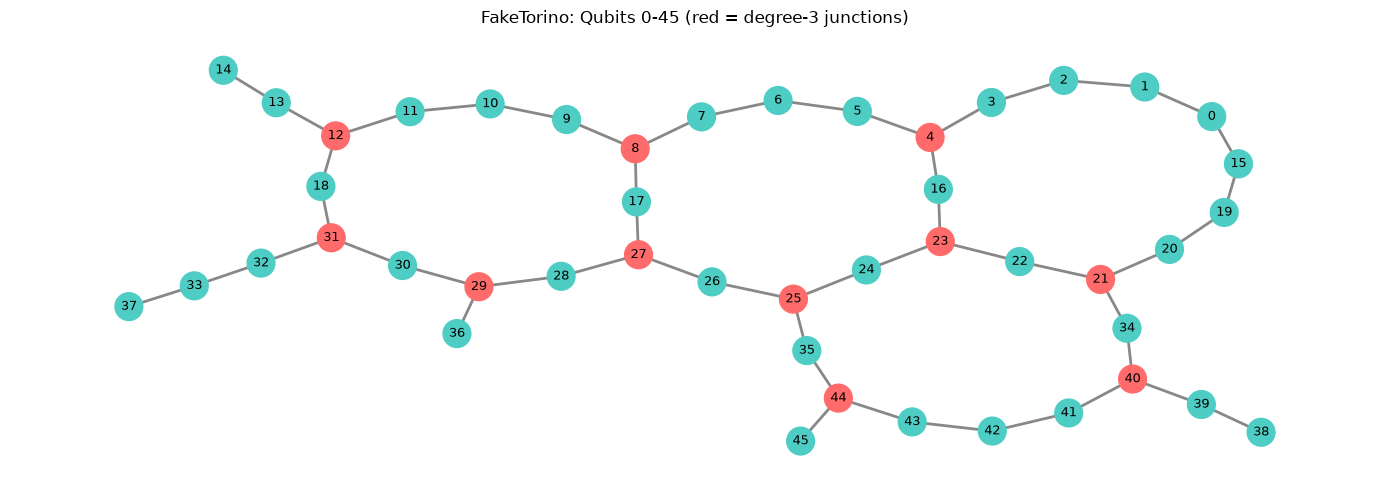

In [39]:
import json, networkx as nx, matplotlib.pyplot as plt

with open(f'{LAB_ROOT}/topology_viz/graph.json') as f:
    data = json.load(f)

G = nx.Graph()
G.add_nodes_from(data['nodes'])
G.add_edges_from(data['edges'])
junctions = set(data['junctions'])

colors = ['#ff6b6b' if q in junctions else '#4ecdc4' for q in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 5))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_size=400, font_size=9,
        node_color=colors, edge_color='#888', width=2, ax=ax)
ax.set_title('FakeTorino: Qubits 0-45 (red = degree-3 junctions)')
plt.tight_layout()
plt.show()

### Exercise 6: 7-Qubit GHZ on a Heavy-Hex Subgraph

Consider this T-shaped subgraph of FakeTorino:

```
23 -- 24 -- 25 -- 26 -- 27
            |
           35
            |
           44
```

Qubit 25 is a **degree-3 junction**: it connects to qubits 24, 26, and 35.

**Task:** Build a 7-qubit GHZ circuit on this subgraph with the **minimum possible depth**.

**Hints:**
- Which qubit should you start from? (Think about where the branching point is!)
- Remember: a qubit can only participate in one CX gate per layer
- Map your abstract qubits as: 0→q23, 1→q24, 2→q25, 3→q26, 4→q27, 5→q35, 6→q44

In [40]:
%%writefile "{LAB_ROOT}/ghz_hex_exercise/ghz_hex_exercise.cpp"
// Exercise 6: 7-qubit GHZ on a heavy-hex T-shaped subgraph
//
// Subgraph adjacency (abstract qubit numbering):
// 0(q23) -- 1(q24) -- 2(q25) -- 3(q26) -- 4(q27)
//                      |
//                    5(q35)
//                      |
//                    6(q44)

#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/statevector.hpp"
#include "compat/target.hpp"
#include "compat/transpile.hpp"

using namespace Qiskit::compat;

int main() {
    QuantumCircuit circ(7, 0);

    // TODO: ADD YOUR CODE HERE: build GHZ starting from the best qubit (the junction)
    circ.h(2);
    circ.cx(2, 1);
    circ.cx(2, 3);
    circ.cx(2, 5);
    circ.cx(1,0);
    circ.cx(3,4);
    circ.cx(5,6);
    

    circ.draw();

    auto d = circ.depth();
    std::cout << "Abstract depth: " << d << std::endl;

    // Verify it is a valid 7-qubit GHZ state
    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../ghz_hex_exercise/circuit.qasm");
    qasm_out << circ.to_qasm3();
    qasm_out.close();

    auto sv = Statevector::from_instruction(circ);
    auto data = sv.data();
    double prob_0 = std::norm(data[0]);
    double prob_last = std::norm(data.back());

    if (std::abs(prob_0 - 0.5) < 0.01 && std::abs(prob_last - 0.5) < 0.01) {
        std::cout << "Valid 7-qubit GHZ state!" << std::endl;
    } else {
        std::cout << "Not a valid GHZ state. Check your circuit." << std::endl;
    }

    // Transpile with the physical layout
    auto circ_meas = circ.measure_all();

    auto target = make_torino_target();
    auto pm = generate_preset_pass_manager(1, target);
    auto isa_qc = pm.run(circ_meas);

    std::cout << "Transpiled depth: " << isa_qc.depth() << std::endl;
    auto ops = isa_qc.count_ops();
    std::cout << "CZ gates: " << (ops.count("cz") ? ops["cz"] : 0) << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_hex_exercise/ghz_hex_exercise.cpp


In [41]:
!cd "{LAB_ROOT}/build" && make ghz_hex_exercise && ./ghz_hex_exercise

[ 50%] Building CXX object CMakeFiles/ghz_hex_exercise.dir/ghz_hex_exercise/ghz_hex_exercise.cpp.o
[100%] Linking CXX executable ghz_hex_exercise
[100%] Built target ghz_hex_exercise
                ┌───┐
q1_0: ──────────┤ X ├──────────
                └─┬─┘
           ┌───┐  │
q1_1: ─────┤ X ├──■────────────
           └─┬─┘
      ┌───┐  │
q1_2: ┤ H ├──■────■────■───────
      └───┘       │    │
                ┌─┴─┐  │
q1_3: ──────────┤ X ├──┼────■──
                └───┘  │    │
                       │  ┌─┴─┐
q1_4: ─────────────────┼──┤ X ├
                       │  └───┘
                     ┌─┴─┐
q1_5: ───────────────┤ X ├──■──
                     └───┘  │
                          ┌─┴─┐
q1_6: ────────────────────┤ X ├
                          └───┘

Abstract depth: 5
Valid 7-qubit GHZ state!
Transpiled depth: 14
CZ gates: 6


In [42]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'ghz_hex_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex6(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-13 23:59:48,263: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! Depth-5 7-qubit GHZ on the T-shape (fidelity 1.0000). Optimal depth achieved.
You scored 2 on this exercise.


### Exercise 7: The Final Challenge: 64-Qubit GHZ

Now let's put everything together. Your task is to build an efficient GHZ state for **64 qubits** (qubits 0–63 of FakeTorino) and transpile it.

**Strategy:**
1. Use the backend's coupling map to find the connectivity of qubits 0–63
2. Build a **spanning tree** via BFS (breadth-first search) from a well-chosen center qubit
3. Construct the GHZ circuit by entangling along the tree, layer by layer
4. Transpile and compare depth against a naive linear GHZ

**Helpful information:**
- The best center qubit in the 0–63 subgraph is **qubit 25** (minimizes the maximum distance to any other qubit)
- `backend.coupling_map.neighbors(q)` gives you the neighbors of qubit $q$

In [43]:
%%writefile "{LAB_ROOT}/ghz_64_exercise/ghz_64_exercise.cpp"
// Exercise 7: 64-qubit GHZ using BFS on the heavy-hex topology

#include <queue>
#include <map>
#include "compat/quantumcircuit.hpp"
#include <fstream>
#include "compat/target.hpp"
#include "compat/transpile.hpp"

using namespace Qiskit::compat;

int main() {
    auto adj = torino_adjacency(64);
    int n = 64;
    int center = 25;  // Try changing this!

    // Show degree-3 junctions
    std::cout << "Degree-3 junctions in qubits 0-63:" << std::endl;
    for (int q = 0; q < n; q++) {
        if (adj[q].size() >= 3) {
            std::cout << "  Qubit " << q << ": neighbors {";
            for (size_t i = 0; i < adj[q].size(); i++) {
                if (i > 0) std::cout << ", ";
                std::cout << adj[q][i];
            }
            std::cout << "}" << std::endl;
        }
    }

    // Step 1: Build a spanning tree via BFS from center
    std::map<int, int> parent;
    std::map<int, int> bfs_depth;
    parent[center] = -1;
    bfs_depth[center] = 0;
    std::queue<int> queue;
    queue.push(center);

    while (!queue.empty()) {
        int node = queue.front();
        queue.pop();
        for (int nb : adj[node]) {
            if (parent.find(nb) == parent.end()) {
                parent[nb] = node;
                bfs_depth[nb] = bfs_depth[node] + 1;
                queue.push(nb);
            }
        }
    }

    int max_d = 0;
    for (auto& kv : bfs_depth)
        max_d = std::max(max_d, kv.second);

    std::cout << "\nBFS from qubit " << center
              << ": reached " << parent.size() << " qubits" << std::endl;
    std::cout << "Max BFS depth: " << max_d << std::endl;

    // Step 2: Build GHZ circuit layer by layer along the BFS tree
    QuantumCircuit circ(n, 0);
    circ.h(center);

    for (int d = 1; d <= max_d; d++) {
        for (int q = 0; q < n; q++) {
            if (bfs_depth.count(q) && bfs_depth[q] == d) {
                // TODO: ADD YOUR CODE HERE: add CX from parent[q] to q
                circ.cx(parent[q], q);
            }
        }
    }

    std::cout << "\nYour GHZ abstract depth: " << circ.depth() << std::endl;

    // Transpile and compare with naive chain
    // Emit OpenQASM 3 for grading via the Python qc_grader client.
    std::ofstream qasm_out("../ghz_64_exercise/circuit.qasm");
    qasm_out << circ.to_qasm3();
    qasm_out.close();

    auto circ_meas = circ.measure_all();

    auto target = make_torino_target();
    auto pm = generate_preset_pass_manager(1, target);
    auto isa_qc = pm.run(circ_meas);

    auto ops = isa_qc.count_ops();
    std::cout << "Your GHZ transpiled depth: " << isa_qc.depth() << std::endl;
    std::cout << "Your GHZ CZ gates: " << (ops.count("cz") ? ops["cz"] : 0) << std::endl;

    // Naive chain for comparison
    QuantumCircuit naive(n, 0);
    naive.h(0);
    for (int q = 0; q < n - 1; q++)
        naive.cx(q, q + 1);
    auto naive_meas = naive.measure_all();

    auto isa_naive = pm.run(naive_meas);
    auto ops_naive = isa_naive.count_ops();
    std::cout << "\nNaive chain transpiled depth: " << isa_naive.depth() << std::endl;
    std::cout << "Naive chain CZ gates: " << (ops_naive.count("cz") ? ops_naive["cz"] : 0) << std::endl;

    return 0;
}

Overwriting /home/h-livv/Projects/qgss-2026/lab-1/cpp/ghz_64_exercise/ghz_64_exercise.cpp


In [44]:
!cd "{LAB_ROOT}/build" && make ghz_64_exercise && ./ghz_64_exercise

[ 50%] Building CXX object CMakeFiles/ghz_64_exercise.dir/ghz_64_exercise/ghz_64_exercise.cpp.o
[100%] Linking CXX executable ghz_64_exercise
[100%] Built target ghz_64_exercise
Degree-3 junctions in qubits 0-63:
  Qubit 4: neighbors {3, 5, 16}
  Qubit 8: neighbors {7, 9, 17}
  Qubit 12: neighbors {11, 13, 18}
  Qubit 21: neighbors {20, 22, 34}
  Qubit 23: neighbors {16, 22, 24}
  Qubit 25: neighbors {24, 26, 35}
  Qubit 27: neighbors {17, 26, 28}
  Qubit 29: neighbors {28, 30, 36}
  Qubit 31: neighbors {18, 30, 32}
  Qubit 40: neighbors {34, 39, 41}
  Qubit 42: neighbors {41, 43, 54}
  Qubit 44: neighbors {35, 43, 45}
  Qubit 46: neighbors {45, 47, 55}
  Qubit 48: neighbors {36, 47, 49}
  Qubit 50: neighbors {49, 51, 56}
  Qubit 61: neighbors {54, 60, 62}

BFS from qubit 25: reached 64 qubits
Max BFS depth: 10

Your GHZ abstract depth: 14
Your GHZ transpiled depth: 47
Your GHZ CZ gates: 63

Naive chain transpiled depth: 256
Naive chain CZ gates: 63


In [45]:
# Grade your answer by reloading the QASM3 the C++ binary wrote
# and submitting the reconstructed circuit to the existing grader.
import qiskit.qasm3
from pathlib import Path
_qasm_path = Path(LAB_ROOT) / 'ghz_64_exercise' / 'circuit.qasm'
_qasm = _qasm_path.read_text() if _qasm_path.is_file() else ''
if not _qasm.strip():
    raise RuntimeError(
        f"{_qasm_path} is empty or missing -- run the build/run cell above "
        "(with your code filled in) before grading."
    )
qc = qiskit.qasm3.loads(_qasm)
grade_lab1_ex7(qc)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-14 00:05:30,016: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


🎉 Correct! 64-qubit GHZ on a spanning tree from q25 (abstract depth 13).
You scored 2 on this exercise.


In [48]:
from qc_grader.challenges.qgss_2026 import check_progress
check_progress("lab1")

Fetching your progress. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-14 00:08:36,604: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


📊 Your progress

Lab "lab1" — 7/7 passed, score 10.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 2.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 2.0
  ✅ ex7 — score 2.0


### Part 3 Summary

**Learning goals achieved:**
- **Transpilation** transforms abstract circuits into hardware-native ones (gate decomposition + qubit routing + layout)
- Heron processors use $\{R_Z, \sqrt{X}, X, CZ\}$ (no H or CX)
- **Heavy-hex topology**: degree-2 chain qubits and degree-3 junction qubits
- SWAP gates (needed for non-neighboring qubits) cost 3 CZ each, so avoid them by designing topology-aware circuits
- **BFS spanning tree**: a systematic way to build efficient GHZ circuits on arbitrary hardware graphs

### Looking Ahead: Lab 2

In Lab 2, we will compare the new IBM **Nighthawk** processor against the **Heron** processor (the architecture we've been working with in this lab). The two have different connectivity patterns: Heron uses heavy-hex, while Nighthawk has a denser graph with more neighbors per qubit. These architectural differences directly affect circuit performance.

The skills you've built here (constructing efficient GHZ states, understanding depth, working with heavy-hex topology) will carry directly into Lab 2, where GHZ circuits are used to benchmark and compare the two processors.

See you in Lab 2! 🚀

---

## Lab 1 Complete: Final Summary

**What you've learned:**

| Concept | Key Takeaway |
|---------|-------------|
| **X, H, CX gates** | The building blocks of quantum circuits |
| **Superposition** | H gate creates $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ |
| **Entanglement** | CX + superposition creates correlated qubit pairs |
| **Bell & GHZ states** | Entanglement for 2 and N qubits |
| **Circuit depth** | Number of sequential gate layers; lower = less noise |
| **Recursive fan-out** | GHZ in $O(\log N)$ depth instead of $O(N)$ |
| **Transpilation** | Abstract → hardware-native circuits |
| **Heavy-hex topology** | Degree-2 chains + degree-3 junctions |
| **Topology-aware design** | Work with hardware connectivity to avoid SWAPs |


# Additional information

**Created by:** James Weaver

**Version:** 1.0.0